### Fig. 8: Depth classes of throughput variability

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import os
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Throughput in bins of depth of crossing 45N

# Depth bins
dep_bins = np.arange(0,1150,50)
dep_bin_cent = (dep_bins[:-1] + dep_bins[1:]) / 2

# Upload saved data (saved in dep_cross_50m_bin.py)
dir_quant = 'YOUR_DATA_PATH' #directory of .npz file

f=np.load(dir_quant+'dep_init_cross45N_50m_bin.npz')
yrs=f['yrs']
dep_rel=f['dep_rel']
dep_cross=f['dep_cross']

vtSPG_cross = np.sum(dep_cross,axis=0) #sum over all depth bins
vtSPG_rel = np.sum(dep_rel,axis=0)


[1993 1999 2004 2011 2016]
[2001 2007 2013 2014]


(1990.0, 2017.0)

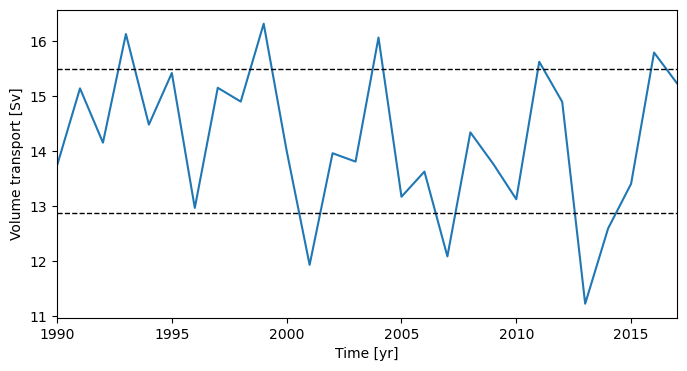

In [3]:
# High versus low throughput composite (+/- 1std)
yrs=np.arange(1990,2017+1)
inds=np.arange(0,len(yrs))

cross_mean=np.mean(vtSPG_cross)
cross_std=np.std(vtSPG_cross)
rel_mean=np.mean(vtSPG_rel)
rel_std=np.std(vtSPG_rel)

# High througput years/indexes
yr_h=yrs[vtSPG_cross>(cross_mean+cross_std)]
inds_h=inds[vtSPG_cross>(cross_mean+cross_std)]
print(yr_h)

# Low throughput years/indexes
yr_l=yrs[vtSPG_cross<(cross_mean-cross_std)]
inds_l=inds[vtSPG_cross<(cross_mean-cross_std)]
print(yr_l)

fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(yrs,vtSPG_cross)
plt.plot(yrs,(cross_mean+cross_std)*np.ones(yrs.shape),'--k',lw=1)
plt.plot(yrs,(cross_mean-cross_std)*np.ones(yrs.shape),'--k',lw=1)
plt.ylabel('Volume transport [Sv]')
plt.xlabel('Time [yr]')
plt.xlim(1990,2017)


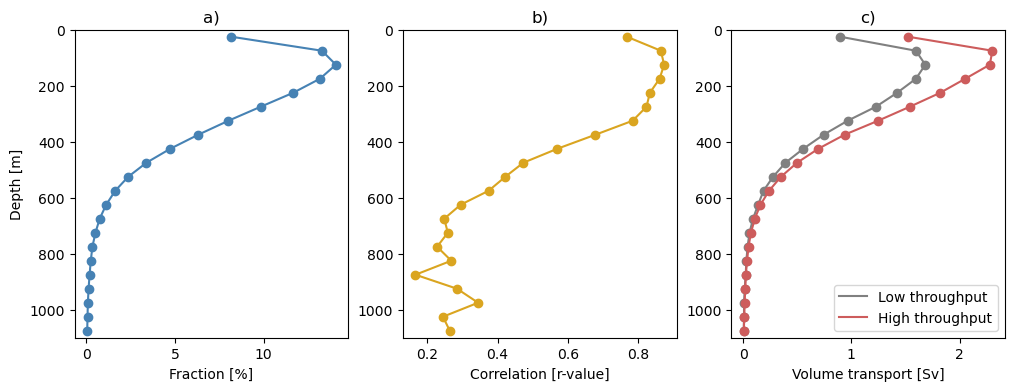

In [4]:
# Plotting Fig. 8 

frac_tot_cross = 100*np.nanmean((dep_cross/vtSPG_cross),axis=1)
frac_tot_rel = 100*np.nanmean((dep_rel/vtSPG_rel),axis=1)
#print(np.sum(frac_tot_cross))

corr_tot_cross=np.zeros(len(dep_bin_cent))
corr_tot_rel=np.zeros(len(dep_bin_cent))

for k in range(0,len(dep_bin_cent)):

    corr_cross = np.corrcoef(dep_cross[k,:],vtSPG_cross[:])
    corr_tot_cross[k] = corr_cross[0,1]
    
    corr_rel = np.corrcoef(dep_rel[k,:],vtSPG_rel[:])
    corr_tot_rel[k] = corr_rel[0,1]

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(12, 4))

ax[0].plot(frac_tot_cross,dep_bin_cent,color='steelblue')
ax[0].plot(frac_tot_cross,dep_bin_cent,'o',color='steelblue')
ax[0].set_ylim(0,1100)
ax[0].yaxis.set_inverted(True)
ax[0].set_xlabel('Fraction [%]')
ax[0].set_ylabel('Depth [m]')
ax[0].set_title('a)')

ax[1].plot(corr_tot_cross,dep_bin_cent,color='goldenrod')
ax[1].plot(corr_tot_cross,dep_bin_cent,'o',color='goldenrod')
ax[1].set_ylim(0,1100)
ax[1].yaxis.set_inverted(True)
ax[1].set_xlabel('Correlation [r-value]')
ax[1].set_title('b)')

ax[2].plot(np.nanmean(dep_cross[:,inds_l],axis=1),dep_bin_cent,color='grey',label='Low throughput')
ax[2].plot(np.nanmean(dep_cross[:,inds_l],axis=1),dep_bin_cent,'o',color='grey')
#
ax[2].plot(np.nanmean(dep_cross[:,inds_h],axis=1),dep_bin_cent,color='indianred',label='High throughput')
ax[2].plot(np.nanmean(dep_cross[:,inds_h],axis=1),dep_bin_cent,'o',color='indianred')
#
ax[2].set_ylim(0,1100)
ax[2].yaxis.set_inverted(True)
ax[2].set_xlabel('Volume transport [Sv]')
ax[2].set_title('c)')
ax[2].legend(fontsize=10)

plt.rcParams.update({'font.size': 11.5})
